# I. IMPORT AND DOWNLOAD LIBRARIES





## 1. Download libraries

In [1]:
!pip install transformers torch torchvision scikit-learn evaluate

## 2. Import libraries

In [2]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torch
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import torch.nn as nn

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {device}")

Device used: cuda


# II. CUSTOM PYTORCH DATASET

## 1. Loading dataset

In [5]:
import torch

class Config:
    model_name = "bert-base-uncased"
    num_classes = 15
    max_length = 256
    seed = 42

    num_epochs = 3
    train_batch_size = 16
    eval_batch_size = 16
    learning_rate = 2e-5


    weight_decay = 0.01
    warmup_ratio = 0.1

    output_dir = "./bert-arxiv-checkpoints"
    evaluation_strategy = "steps"
    save_strategy = "steps"

    eval_steps = 500
    save_steps = 500
    logging_steps = 100


    metric_for_best_model = "f1_macro"
    load_best_model_at_end = True
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()

In [6]:
ds = load_dataset("UniverseTBD/arxiv-abstracts-large")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'],
        num_rows: 2292057
    })
})

In [7]:
df = ds["train"].to_pandas()
df.head()

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,None,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,None,math.CO,None,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
4,0704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,None,"Illinois J. Math. 52 (2008) no.2, 681-689",None,None,math.CA math.FA,None,In this paper we show how to compute the $\L...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]"


In [8]:
for i in range(3):
  print(f"Example {i+1}:")
  print(ds["train"][i]["abstract"])
  print(ds["train"][i]["categories"])
  print("---" * 20)

Example 1:
  A fully differential calculation in perturbative quantum chromodynamics is
presented for the production of massive photon pairs at hadron colliders. All
next-to-leading order perturbative contributions from quark-antiquark,
gluon-(anti)quark, and gluon-gluon subprocesses are included, as well as
all-orders resummation of initial-state gluon radiation valid at
next-to-next-to-leading logarithmic accuracy. The region of phase space is
specified in which the calculation is most reliable. Good agreement is
demonstrated with data from the Fermilab Tevatron, and predictions are made for
more detailed tests with CDF and DO data. Predictions are shown for
distributions of diphoton pairs produced at the energy of the Large Hadron
Collider (LHC). Distributions of the diphoton pairs from the decay of a Higgs
boson are contrasted with those produced from QCD processes at the LHC, showing
that enhanced sensitivity to the signal can be obtained with judicious
selection of events.

hep-p

## 2. Preprocessing dataset

In [9]:
df = df[df['categories'].str.split().str.len() == 1].copy()

df

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,None,math.CO,None,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
5,0704.0006,Yue Hin Pong,Y. H. Pong and C. K. Law,Bosonic characters of atomic Cooper pairs acro...,"6 pages, 4 figures, accepted by PRA",None,10.1103/PhysRevA.75.043613,None,cond-mat.mes-hall,None,We study the two-particle wave function of p...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2015-05-13,"[[Pong, Y. H., ], [Law, C. K., ]]"
6,0704.0007,Alejandro Corichi,"Alejandro Corichi, Tatjana Vukasinac and Jose ...",Polymer Quantum Mechanics and its Continuum Limit,"16 pages, no figures. Typos corrected to match...","Phys.Rev.D76:044016,2007",10.1103/PhysRevD.76.044016,IGPG-07/03-2,gr-qc,None,A rather non-standard quantum representation...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-11-26,"[[Corichi, Alejandro, ], [Vukasinac, Tatjana, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291138,quant-ph/9912118,Thomas Jennewein,"Thomas Jennewein (1), Ulrich Achleitner (2), G...",A Fast and Compact Quantum Random Number Gener...,"23 pages, 6 Figs. To appear in Rev. Sci. Instr",None,10.1063/1.1150518,None,quant-ph,None,We present the realization of a physical qua...,"[{'version': 'v1', 'created': 'Tue, 28 Dec 199...",2009-10-31,"[[Jennewein, Thomas, ], [Achleitner, Ulrich, ]..."
2291139,quant-ph/9912119,M. B. Miller,"B.F. Kostenko, V.D. Kuznetsov, M.B. Miller, A....",Nuclear Teleportation,"8 pages, 2 figures, to be submitted to the Thi...",None,None,None,quant-ph,None,"Until recently, only science-fiction authors...","[{'version': 'v1', 'created': 'Thu, 30 Dec 199...",2007-05-23,"[[Kostenko, B. F., ], [Kuznetsov, V. D., ], [M..."
2291141,quant-ph/9912121,James Franson,"J. D. Franson, T. B. Pittman, and J. P. Dowling",Simple pulse sequence for quantum logic operat...,This paper has been withdrawn,None,None,None,quant-ph,None,This paper has been withdrawn by the authors...,"[{'version': 'v1', 'created': 'Thu, 30 Dec 199...",2007-05-23,"[[Franson, J. D., ], [Pittman, T. B., ], [Dowl..."
2291142,quant-ph/9912122,Benjamin Schumacher,Benjamin Schumacher (Kenyon College) and Micha...,Optimal signal ensembles,"12 pages, 1 eps figure",None,None,None,quant-ph,None,Classical messages can be sent via a noisy q...,"[{'version': 'v1', 'created': 'Fri, 31 Dec 199...",2007-05-23,"[[Schumacher, Benjamin, , Kenyon College], [We..."


In [10]:
df['label'] = df['categories'].apply(
    lambda x: x.split()[0].split('.')[0]
)
df['label']

,label
0,hep-ph
2,physics
3,math
5,cond-mat
6,gr-qc
...,...
2291138,quant-ph
2291139,quant-ph
2291141,quant-ph
2291142,quant-ph


In [11]:
label_counts = df['label'].value_counts()

print(label_counts.head(20))

label
math        264800
astro-ph    204267
cs          190329
cond-mat    167272
physics      81840
hep-ph       79303
quant-ph     64677
hep-th       57406
gr-qc        29167
nucl-th      18899
stat         17987
hep-ex       17133
q-bio        11131
hep-lat       9959
eess          9077
nlin          8830
nucl-ex       7322
q-fin         3903
econ          1876
Name: count, dtype: int64


In [12]:
top15_labels = label_counts.head(15).index.tolist()

print(top15_labels)

['math', 'astro-ph', 'cs', 'cond-mat', 'physics', 'hep-ph', 'quant-ph', 'hep-th', 'gr-qc', 'nucl-th', 'stat', 'hep-ex', 'q-bio', 'hep-lat', 'eess']


In [13]:
df = df[df['label'].isin(top15_labels)].copy()

In [14]:
df = (
    df.groupby('label')
      .sample(n=4000, random_state=42)
.reset_index(drop = True))

df.shape

(60000, 15)

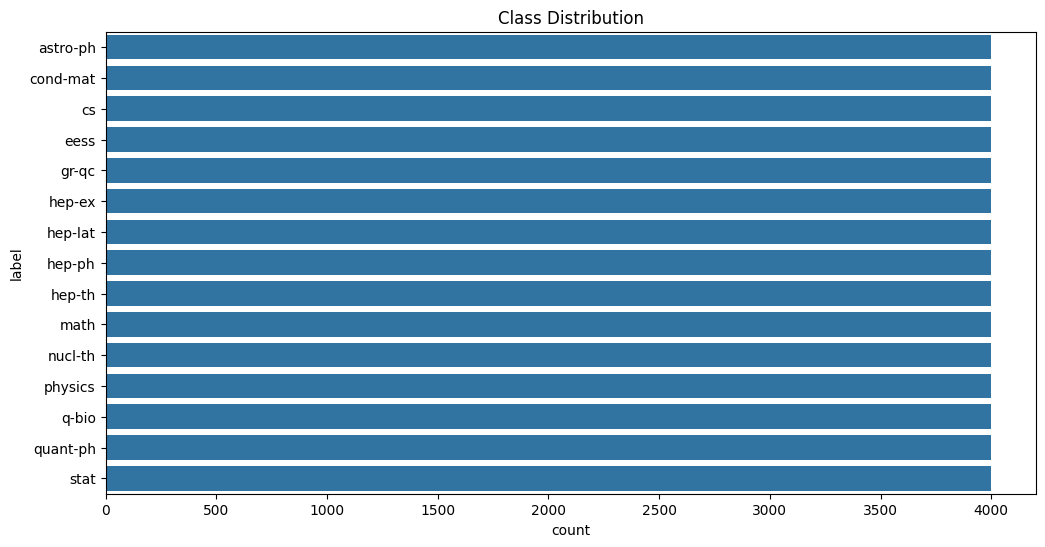

In [15]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df['label'],
    order=df['label'].value_counts().index
)

plt.title("Class Distribution")

plt.show()

In [16]:
df_balanced = df.copy()
df_balanced

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed,label
0,astro-ph/9609076,Tom Theuns,Tom Theuns (Oxford University) and S. J. Warre...,Intergalactic stars in the Fornax Cluster,"5 pages, latex (mn.sty), 3 figures (figure 1 i...","MNRAS 284, L11 (1997)",10.1093/mnras/284.3.L11,None,astro-ph,None,We have identified ten candidate intergalact...,"[{'version': 'v1', 'created': 'Tue, 10 Sep 199...",2016-01-13,"[[Theuns, Tom, , Oxford University], [Warren, ...",astro-ph
1,2012.13704,Sabyasachi Chattopadhyay,"Sabyasachi Chattopadhyay, Matthew A. Bershady,...",Optimization of telescope focal ratios for MLA...,None,"Proceedings Volume 11451, Advances in Optical ...",10.1117/12.2562900,None,astro-ph.IM,http://arxiv.org/licenses/nonexclusive-distrib...,We have developed an analytic model for gene...,"[{'version': 'v1', 'created': 'Sat, 26 Dec 202...",2020-12-29,"[[Chattopadhyay, Sabyasachi, ], [Bershady, Mat...",astro-ph
2,0902.3618,Alex Lazarian,"A. Lazarian, S. Boldyrev, C. Forest, J. Sarff,...",Understanding of the role of magnetic fields: ...,"8 pages, white paper submitted to the Galactic...",None,None,None,astro-ph.GA,http://arxiv.org/licenses/nonexclusive-distrib...,"A combination of observation, theory, modeli...","[{'version': 'v1', 'created': 'Fri, 20 Feb 200...",2009-02-23,"[[Lazarian, A., ], [Boldyrev, S., ], [Forest, ...",astro-ph
3,2004.00072,Leigh Fletcher,"L.N. Fletcher, G.S. Orton, T.K. Greathouse, J....",Jupiter's Equatorial Plumes and Hot Spots: Spe...,"50 pages, 16 figures, accepted for publication...",None,10.1029/2020JE006399,None,astro-ph.EP,http://creativecommons.org/licenses/by/4.0/,We present multi-wavelength measurements of ...,"[{'version': 'v1', 'created': 'Tue, 31 Mar 202...",2020-05-15,"[[Fletcher, L. N., ], [Orton, G. S., ], [Great...",astro-ph
4,1307.2085,Benne W. Holwerda,"B. W. Holwerda (ESA), N. Pirzkal (ESA/STSCI), ...",Quantified HI Morphology VII: star-formation a...,"26 figures, 4 tables, two appendices. Third ap...",None,10.1093/mnras/stt1291,None,astro-ph.CO,http://arxiv.org/licenses/nonexclusive-distrib...,Scale-invariant morphology parameters applie...,"[{'version': 'v1', 'created': 'Mon, 8 Jul 2013...",2015-06-16,"[[Holwerda, B. W., , ESA], [Pirzkal, N., , ESA...",astro-ph
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,2305.07587,Alessandro Villar,"Manolis Antonoyiannakis, Hugues Chat\'e, Seren...",Global method for gender profile estimation fr...,https://ggem.app,None,None,None,stat.AP,http://creativecommons.org/licenses/by-nc-nd/4.0/,As social issues related to gender bias attr...,"[{'version': 'v1', 'created': 'Fri, 12 May 202...",2023-05-15,"[[Antonoyiannakis, Manolis, ], [Chaté, Hugues,...",stat
59996,1805.07149,Andrea Gabrio,"Andrea Gabrio, Rachael Hunter, Alexina J. Maso...",Joint longitudinal models for dealing with mis...,None,None,None,None,stat.AP,http://arxiv.org/licenses/nonexclusive-distrib...,Health economic evaluations based on patient...,"[{'version': 'v1', 'created': 'Fri, 18 May 201...",2020-05-25,"[[Gabrio, Andrea, ], [Hunter, Rachael, ], [Mas...",stat
59997,1111.0416,Deepak Agarwal,"Deepak Agarwal, Liang Zhang, Rahul Mazumder",Modeling item--item similarities for personali...,Published in at http://dx.doi.org/10.1214/11-A...,"Annals of Applied Statistics 2011, Vol. 5, No....",10.1214/11-AOAS475,IMS-AOAS-AOAS475,stat.AP,http://arxiv.org/licenses/nonexclusive-distrib...,We consider the problem of algorithmically r...,"[{'version': 'v1', 'created': 'Wed, 2 Nov 2011...",2011-11-03,"[[Agarwal, Deepak, ], [Zhang, Liang, ], [Mazum...",stat
59998,1710.09945,Frederic Pascal,Gordana Draskovic and Frederic Pascal,New insights into the statistical properties o...,None,"IEEE Transactions on Signal Processing, vol. 6...",10.1109/TSP.2018.2841892,None,stat.ME,http://arxiv.org/licenses/nonexclusive-distrib...,This paper proposes an original approach to ...,"[{'version': 'v1', 'created': 'Th

In [17]:
'''
df["primary category"] = df["categories"].apply(lambda x: str(x).split(' ')[0].split('.')[0])
top_15_series = df['primary category'].value_counts().nlargest(15)
print(top_15_series)

top_15_topics = top_15_series.index.to_list()
print(f"The list of the top 15 topics: {top_15_topics}")

df_filtered = df[df['primary category'].isin(top_15_topics)]
print(f"The length of filtered dataset: {len(df_filtered)}")
df_balanced = df_filtered.groupby('primary category').sample(n=4000, random_state=42).reset_index(drop=True)
print(f"The length of balanced dataset: {len(df_balanced)}")
'''

encoder = LabelEncoder()
df_balanced['label'] = encoder.fit_transform(df_balanced['label'])
print(df_balanced['label'])

0         0
1         0
2         0
3         0
4         0
         ..
59995    14
59996    14
59997    14
59998    14
59999    14
Name: label, Length: 60000, dtype: int64


## 3. CREATE CUSTOM PYTORCH DATASET

In [18]:
class AbstractClassificationDataset(Dataset):
  '''
  abstracts: the input abstract of the dataframe
  labels: the integer representing label
  tokenizer: AutoTokenizer()
  max_length: max length of each sentence - how many to truncate/ pad to
  '''

  def __init__(self, abstracts, labels, tokenizer, max_length = cfg.max_length):
    self.abstracts = abstracts
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __len__(self):
    '''
    return the total size of the dataset
    '''
    return len(self.abstracts)

  def __getitem__(self, idx):
    '''
    args: idx
    abstract is the df['abstract']
    label is the df['label']
    grab the specific abstract and label
    then tokenize



    return:
    {
    input_ids:
    attention_mask:
    labels:
    }
    '''

    abstract = str(self.abstracts[idx])
    label = self.labels[idx]

    encoding = self.tokenizer(
        abstract,
        add_special_tokens = True,
        max_length = self.max_length,
        padding = 'max_length',
        truncation = True,
        return_attention_mask = True,
        return_tensors = 'pt' #wrap the output into pytorch tensor
    )

    return {
        'input_ids': encoding["input_ids"].flatten(),
        'attention_mask': encoding['attention_mask'].flatten(),
        'labels': torch.tensor(label, dtype = torch.long)
    }


tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)

#stratified sampling
df_train_val, df_test = train_test_split(
    df_balanced,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label']
)


df_train, df_val = train_test_split(
    df_train_val,
    test_size=1/8,
    random_state=42,
    stratify=df_train_val['label']
)

total_samples = len(df_balanced)
print(f"Train: {len(df_train)} sample ({len(df_train)/total_samples:.0%})")
print(f"Val:   {len(df_val)} sample ({len(df_val)/total_samples:.0%})")
print(f"Test:  {len(df_test)} sample ({len(df_test)/total_samples:.0%})")

# Reset indices to ensure sequential access for DataLoaders
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train: 42000 sample (70%)
Val:   6000 sample (10%)
Test:  12000 sample (20%)


In [19]:
train_dataset = AbstractClassificationDataset(
    abstracts = df_train['abstract'],
    labels = df_train['label'],
    tokenizer = tokenizer,
    max_length = cfg.max_length
)

test_dataset = AbstractClassificationDataset(
    abstracts = df_test['abstract'],
    labels = df_test['label'],
    tokenizer = tokenizer,
    max_length = cfg.max_length
)

val_dataset = AbstractClassificationDataset(
    abstracts = df_val['abstract'],
    labels = df_val['label'],
    tokenizer = tokenizer,
    max_length = cfg.max_length
)


train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = 16,
    shuffle = True,
    num_workers = 2
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = 16,
    shuffle = False,
    num_workers = 2
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = 16,
    shuffle = False,
    num_workers = 2
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


Number of training batches: 2625
Number of validation batches: 375
Number of testing batches: 750


# III. Training Loop

In [20]:
model = AutoModelForSequenceClassification.from_pretrained(cfg.model_name,
                                                           num_labels = cfg.num_classes)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [22]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load('recall')

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis = -1)

  acc = accuracy_metric.compute(predictions = predictions, references = labels)
  f1 = f1_metric.compute(predictions = predictions, references = labels, average = "macro")
  prec = precision_metric.compute(predictions = predictions, references = labels, average = "macro")
  rec = recall_metric.compute(predictions = predictions, references = labels, average = "macro")

  return {
      'accuracy': acc['accuracy'],
      'f1_macro': f1['f1'],
      'precision': prec['precision'],
      'recall': rec['recall']

  }

In [24]:
training_args = TrainingArguments(
    output_dir=cfg.output_dir,

    learning_rate=cfg.learning_rate,
    per_device_train_batch_size=cfg.train_batch_size,
    per_device_eval_batch_size=cfg.eval_batch_size,
    num_train_epochs=cfg.num_epochs,
    weight_decay=cfg.weight_decay,
    warmup_ratio=cfg.warmup_ratio,

    eval_strategy=cfg.evaluation_strategy,
    save_strategy=cfg.save_strategy,
    eval_steps=cfg.eval_steps,
    save_steps=cfg.save_steps,
    logging_steps=cfg.logging_steps,

    load_best_model_at_end=cfg.load_best_model_at_end,
    metric_for_best_model=cfg.metric_for_best_model,
    seed=cfg.seed
)


# put it all into the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,     # Dataset 80%
    eval_dataset=val_dataset,        # Dataset 10%
    compute_metrics=compute_metrics
)

#Training
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
500,1.476514,1.233543,0.691667,0.668459,0.709304,0.691667
1000,0.804906,0.709572,0.782333,0.780091,0.787249,0.782333
1500,0.614563,0.614730,0.809833,0.807754,0.809474,0.809833
2000,0.577146,0.557821,0.828667,0.826603,0.829481,0.828667
2500,0.517264,0.549798,0.828333,0.826993,0.832989,0.828333
3000,0.379490,0.525371,0.837667,0.837961,0.841156,0.837667
3500,0.418142,0.510030,0.844167,0.844313,0.847162,0.844167
4000,0.406782,0.503258,0.847500,0.846803,0.848867,0.847500
4500,0.386734,0.502442,0.844000,0.846370,0.852851,0.844000
5000,0.402135,0.470114,0.856333,0.855231,0.855997,0.856333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=7875, training_loss=0.5422612854488312, metrics={'train_runtime': 8331.0513, 'train_samples_per_second': 15.124, 'train_steps_per_second': 0.945, 'total_flos': 1.6577931267072e+16, 'train_loss': 0.5422612854488312, 'epoch': 3.0})

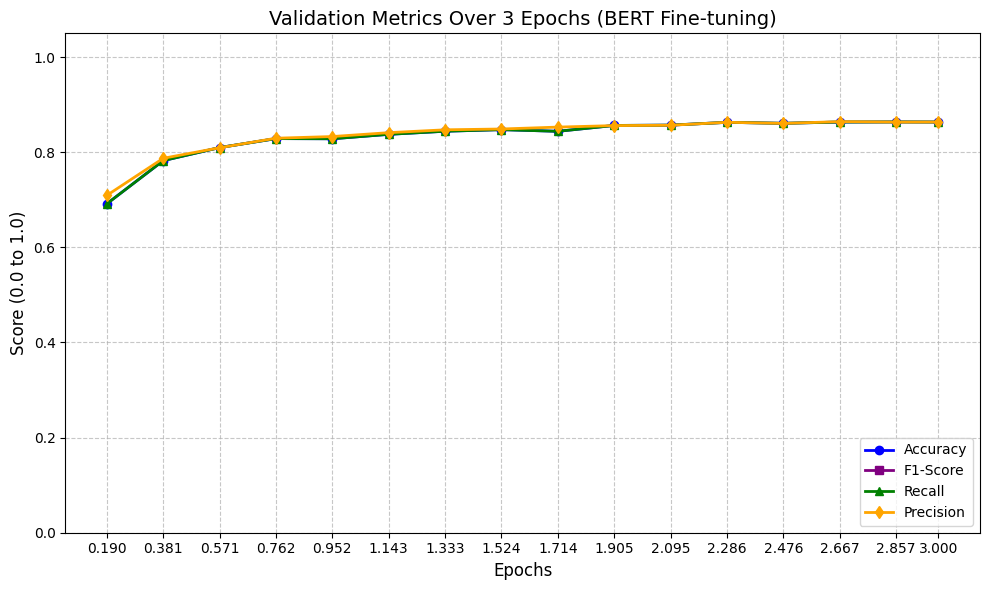

In [25]:
import matplotlib.pyplot as plt

# 1. Lấy lịch sử log từ Trainer
log_history = trainer.state.log_history

# 2. Khởi tạo mảng lưu trữ
epochs = []
eval_accuracy = []
eval_f1 = []
eval_recall = []
eval_precision = []

# 3. Duyệt qua log_history để lấy số liệu của tập Validation
for log in log_history:
    if 'eval_loss' in log and 'epoch' in log:
        epochs.append(log['epoch'])
        # Đảm bảo các key này khớp với tên bạn đã return trong compute_metrics (cộng thêm 'eval_')
        eval_accuracy.append(log.get('eval_accuracy'))
        eval_f1.append(log.get('eval_f1'))
        eval_recall.append(log.get('eval_recall'))
        eval_precision.append(log.get('eval_precision'))

# ==========================================
# VẼ BIỂU ĐỒ SO SÁNH 4 METRICS
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(epochs, eval_accuracy, label='Accuracy', color='blue', marker='o', linewidth=2)
plt.plot(epochs, eval_f1, label='F1-Score', color='purple', marker='s', linewidth=2)
plt.plot(epochs, eval_recall, label='Recall', color='green', marker='^', linewidth=2)
plt.plot(epochs, eval_precision, label='Precision', color='orange', marker='d', linewidth=2)

plt.title('Validation Metrics Over 3 Epochs (BERT Fine-tuning)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xticks(epochs) # Ép trục X chỉ hiển thị số nguyên của epoch (1, 2, 3)
plt.ylim(0, 1.05)  # Giới hạn trục Y từ 0 đến 1
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Đang chạy dự đoán trên tập Test...



--- BÁO CÁO PHÂN LOẠI TRÊN TẬP TEST ---
              precision    recall  f1-score   support

        math       0.96      0.94      0.95       800
    astro-ph       0.83      0.82      0.83       800
          cs       0.86      0.79      0.82       800
    cond-mat       0.83      0.87      0.85       800
     physics       0.84      0.88      0.86       800
      hep-ph       0.93      0.93      0.93       800
    quant-ph       0.94      0.93      0.93       800
      hep-th       0.85      0.82      0.83       800
       gr-qc       0.85      0.83      0.84       800
     nucl-th       0.90      0.90      0.90       800
        stat       0.84      0.92      0.88       800
      hep-ex       0.68      0.66      0.67       800
       q-bio       0.88      0.91      0.89       800
     hep-lat       0.86      0.86      0.86       800
        eess       0.87      0.86      0.87       800

    accuracy                           0.86     12000
   macro avg       0.86      0.86      

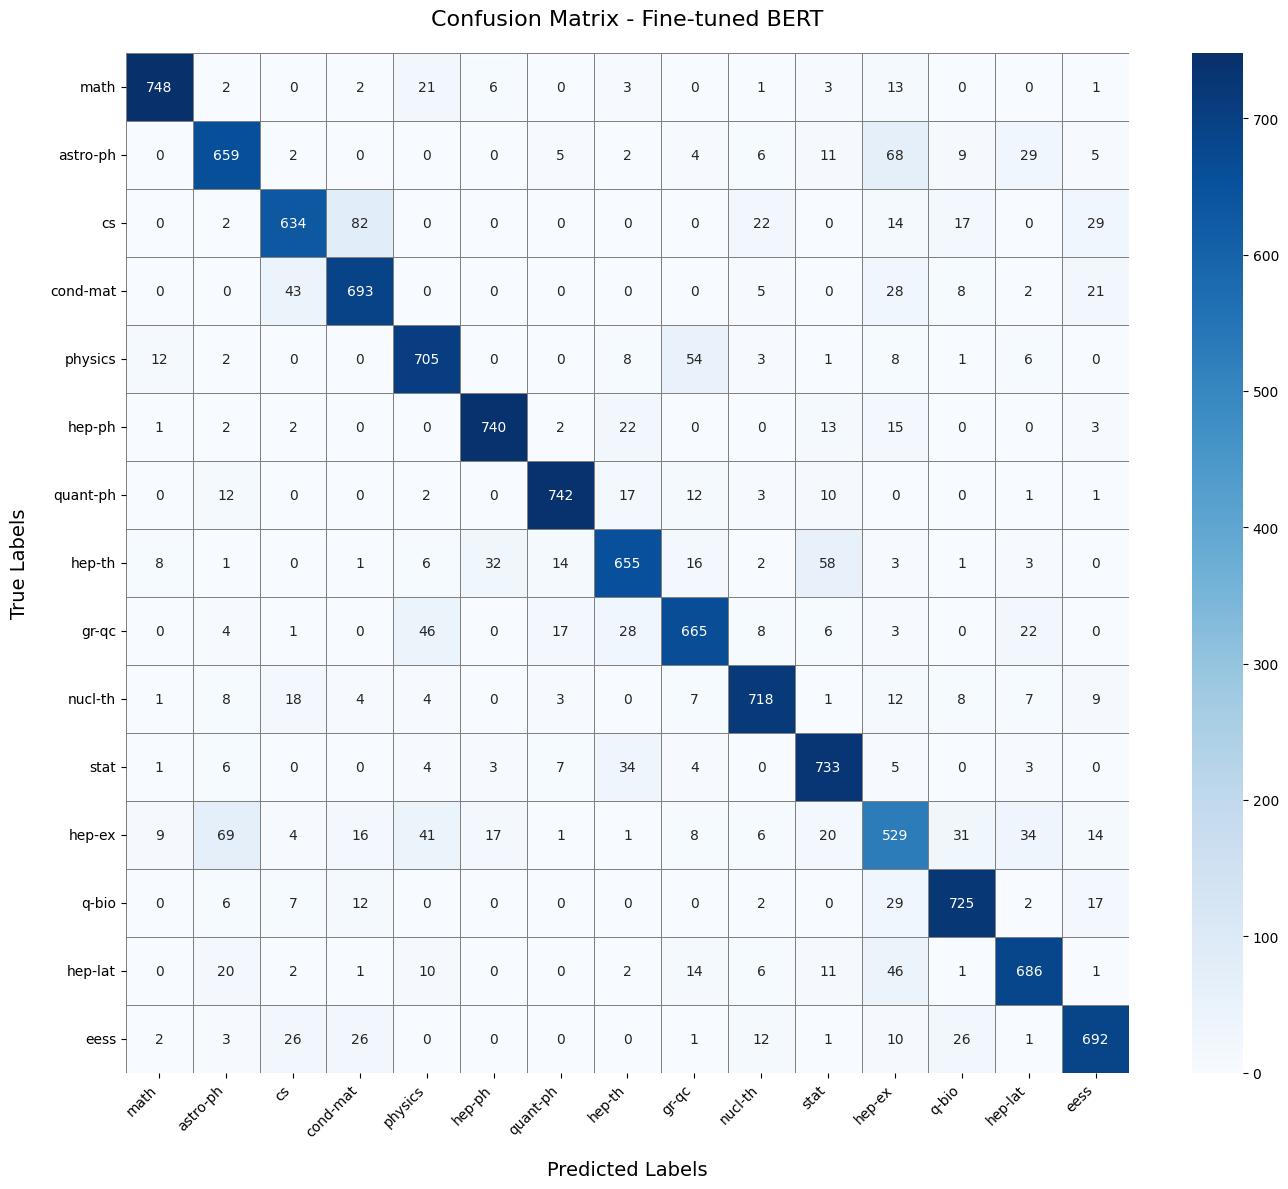

In [29]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. INFERENCE TRÊN TẬP TEST
# ==========================================
print("Đang chạy dự đoán trên tập Test...")
predictions_output = trainer.predict(test_dataset)

# Lấy logits (dự đoán thô) và y_true (đáp án chuẩn)
logits = predictions_output.predictions
y_true = predictions_output.label_ids

# Chuyển logits thành nhãn dự đoán bằng hàm argmax
y_pred = np.argmax(logits, axis=-1)

# ==========================================
# 2. IN BÁO CÁO PHÂN LOẠI (TEXT)
# ==========================================
print("\n--- BÁO CÁO PHÂN LOẠI TRÊN TẬP TEST ---")
print(classification_report(y_true, y_pred, target_names=top15_labels))

# ==========================================
# 3. VẼ CONFUSION MATRIX
# ==========================================
# Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# Vẽ ma trận bằng Seaborn Heatmap
plt.figure(figsize=(14, 12)) # Cỡ ảnh lớn vì có tới 15 class
sns.heatmap(
    cm,
    annot=True,       # Hiển thị số lượng bên trong từng ô
    fmt='d',          # Hiển thị định dạng số nguyên (integer)
    cmap='Blues',     # Dùng dải màu xanh tương tự trong file PDF của dự án
    xticklabels=top15_labels,
    yticklabels=top15_labels,
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Confusion Matrix - Fine-tuned BERT', fontsize=16, pad=20)
plt.xlabel('Predicted Labels', fontsize=14, labelpad=15)
plt.ylabel('True Labels', fontsize=14, labelpad=15)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X 45 độ để không bị đè chữ
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()